In [ ]:

pip install langchain_core langchain_openai

In [ ]:
from langchain_openai import ChatOpenAI


In [ ]:
pip install pyPDF

In [ ]:
pip install langchain_community

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

In [ ]:
loader=PyPDFLoader("/content/ML UNIT 1.pdf")

In [ ]:
docs=loader.load()

In [ ]:
docs

[Document(metadata={'producer': 'www.ilovepdf.com', 'creator': 'Microsoft® Word 2016', 'creationdate': '2023-03-27T06:01:41+00:00', 'author': 'Swaroopa Rani', 'moddate': '2023-03-27T06:01:42+00:00', 'source': '/content/ML UNIT 1.pdf', 'total_pages': 20, 'page': 0, 'page_label': '1'}, page_content='PVP Siddhartha Institute of Technology, Department of IT                                                         1 | P a g e  \n \nUNIT-1 \n\uf0b7 What Is Machine Learning?  \n\uf0b7 Examples of Machine Learning Applications  \n\uf0b7 Learning Associations  \n\uf0b7 Classification  \n\uf0b7 Regression  \n\uf0b7 Unsupervised Learning  \n\uf0b7 Reinforcement Learning  \n \nWhat Is Machine Learning? : \nIn the real world, we are surrounded by humans who can learn everything from their experiences with \ntheir learning capability, and we have computers or machines which work on our instructions. But can \na machine also learn from experiences or past data like  a human does? So here comes the rol

In [ ]:
print(type(docs))
print(len(docs))

<class 'list'>
20


In [ ]:
print(docs[2].page_content)

PVP Siddhartha Institute of Technology, Department of IT                                                         3 | P a g e  
 
performance of the machine learning algorithm depends on the amount of data, and it can be 
determined by the cost function. With the help of machine learning, we can save both time and money. 
The importance of machine learning can be easily understood by its uses cases, currently, 
machine learning is used in  self-driving cars , cyber fraud detection , face recognition , and  friend 
suggestion by Facebook , etc. Various top companies such as Netflix and Amazon have built mach ine 
learning models that are using a vast amount of data to analyze the user interest and recommend 
product accordingly. 
 
How to get started with Machine Learning? 
To get started, let’s take a look at some of the important terminologies. 
Terminology: 
 Model: Also known as “hypothesis”, a machine learning model is the mathematical representation 
of a real-world process. A mac

In [ ]:
pip install langchain

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
splitter=RecursiveCharacterTextSplitter(
   chunk_size=1500,
   chunk_overlap=200
)

In [ ]:
chunks=splitter.split_documents(docs)

In [ ]:
print(len(chunks))
print(chunks[1].page_content)

47
• With experience E.  
• A well-defined learning task is given by    <P, T, E> 
Defining the Learning Task: 
Improve on task T, with respect to performance metric P, based on experience E 
T: Playing checkers 
P: Percentage of games won against an arbitrary opponent   
E: Playing practice games against itself 
 
T: Recognizing hand-written words 
P: Percentage of words correctly classified 
E: Database of human-labeled images of handwritten words 
 
T: Driving on four-lane highways using vision sensors 
P: Average distance traveled before a human-judged error 
E: A sequence of images and steering commands recorded while  observing a human driver. 
 
T: Categorize email messages as spam or legitimate.   
P: Percentage of email messages correctly classified.   
E: Database of emails, some with human-given labels


In [ ]:
pip install faiss-cpu

In [ ]:
from langchain_community.vectorstores import FAISS

In [ ]:
OPENAI_API_KEY=""

In [ ]:
from langchain_openai import OpenAIEmbeddings

In [ ]:
embedding_model=OpenAIEmbeddings(model="text-embedding-3-small",api_key=OPENAI_API_KEY)

In [ ]:
print(type(chunks[0]))

<class 'langchain_core.documents.base.Document'>


In [ ]:
!pip install langchain-chroma

In [ ]:
from langchain_community.vectorstores import Chroma

In [ ]:
vectorstore = FAISS.from_documents(chunks, embedding_model)

In [ ]:
vectorstore.index_to_docstore_id

{0: '816740e9-c568-4bf8-9acb-c5ecc6f33bd4',
 1: '8ff5a10b-3899-4b96-a7ed-5f8d05e7054f',
 2: '8d77d12e-f0f4-40ee-b426-c092ceb714a9',
 3: '4f430cd7-3f0f-491e-bdd1-3ec2993c1cac',
 4: 'b553dda2-107c-4bde-9c89-4d98df791eba',
 5: 'f4df56f3-8974-4975-ad1d-557072c2c3a2',
 6: 'be62e48f-814b-44c3-b0c8-f8f209a7b929',
 7: '739c724b-ce81-4f5d-936d-86dd92f85315',
 8: 'd428d23e-bb71-473f-b0a1-35a759270a22',
 9: '15b7aba2-a4bd-45da-96e5-7a2ed0d2fd8a',
 10: '25ec9aad-2f2e-4b6e-adc5-93d55f3a5139',
 11: '8ee5ec22-a9a8-401f-a685-92651d7e7864',
 12: 'e3d4e523-0a4c-48b6-8632-3c9bbcb7667d',
 13: '0dda2303-f460-4218-bfb3-710ae6d691a3',
 14: '37f20331-e848-4ee4-baac-25b2ae48c57a',
 15: '61e97d8f-43ec-4f34-995b-639641936699',
 16: '6fa31cae-22a1-46ba-bb1d-f32c41d2c144',
 17: '03d3fc2b-f2a5-40ad-a9aa-afaa8bfdf4b8',
 18: 'f5b5ebe0-7d56-4a2b-ad17-b6d76c6fef47',
 19: '6e825dec-070c-43ce-800e-acc3cfbe431f',
 20: '653e255b-920c-4030-8c14-d6839ac1cd43',
 21: '7de6168e-6f47-4313-9515-1dc9cc7bdd5a',
 22: '6e3e9070-ba8a-

In [ ]:
retriever=vectorstore.as_retriever(search_type="similarity",search_kwargs={"k":2})

In [ ]:
res=retriever.invoke("tell me about reinforcement learning")

In [ ]:
print(type(res))
print(res[0].page_content)

<class 'list'>
Process(MDP). In MDP, the agent constantly interacts with the environment and performs actions; at 
each action, the environment responds and generates a new state. 
 
Categories of Reinforcement Learning: - 
Reinforcement learning is categorized mainly into two types of methods/algorithms: 
 Positive Reinforcement Learning:  Positive reinforcement learning specifies increasing the 
tendency that the required behaviour would occur again by adding something. It enhances the 
strength of the behaviour of the agent and positively impacts it. 
 Negative Reinforcement Learning:  Negative reinforcement learning works exactly opposite to 
the positive RL. It increases the tendency that the specific behaviour would occur again by avoiding 
the negative condition. 
 
Real-world Use cases of Reinforcement Learning: - 
 Video Games:  -RL algorithms are much popular in gaming applications. It is used to gain super -
human performance. Some popular games that use RL algorithms are

In [ ]:
model=ChatOpenAI(model="gpt-4",api_key=OPENAI_API_KEY)

In [ ]:
pip install langgraph

In [ ]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from langchain_core.prompts import PromptTemplate

In [ ]:
class resultState(TypedDict):
  input:str
  output:list
  opinion:Literal["positive","negative"]
  result:str

In [ ]:
def retrieve_info(state:resultState):
  res=retriever.invoke(state["input"])
  result=[]
  result.append(res[0].page_content)
  result.append(res[1].page_content)
  state["output"]=result
  return state

In [ ]:
prompt1=PromptTemplate(
    template='''
    understand the question {question} and check whether the answers that are {answer1} or {answer2} are correct for the question.

    you should tell whether answer is positive or negative.
    ''',
    input_variables=["question","answer1","answer2"],
    validate_template=True
)

In [ ]:
from pydantic import BaseModel,Field
class Evaluation(BaseModel):
  opinion:Literal["positive","negative"]=Field(description="opinion on the retrieved answers")

In [ ]:
structured_model=model.with_structured_output(Evaluation)

/usr/local/lib/python3.12/dist-packages/langchain_openai/chat_models/base.py:2210: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [ ]:
def opinion_on_info(state:resultState):
  question=state["input"]
  answer1=state["output"][0]
  answer2=state["output"][1]
  prompt=prompt1.invoke({"question":question,"answer1":answer1,"answer2":answer2})
  opinion=structured_model.invoke(prompt)
  state["opinion"]=opinion.opinion
  return state

In [ ]:
from typing import Literal

def check_condition(state: resultState) -> Literal["positive_opinion", "negative_opinion"]:
    opinion = state.get("opinion", "")

    print(f"Opinion raw: {repr(opinion)}")

    if isinstance(opinion, str) and "positive" in opinion.strip().lower():
        return "positive_opinion"
    else:

        return "negative_opinion"

In [ ]:
def negative_opinion(state:resultState):
  result="The question you asked is not mentioned in the RAG information"
  state["result"]=result
  return state

In [ ]:
def positive_opinion(state:resultState):
  template=PromptTemplate(template=
  '''
  Identify which answer from {answer1} and {answer2} is relevant to the {question}

  summarize the relevant answer.If both are relevant.Summarize both the answers
  ''',
  input_variables=["answer1","answer2","question"],
  validate_template=True
  )
  prompt=template.invoke({"question":state["input"],"answer1":state["output"][0],"answer2":state["output"]})
  result=model.invoke(prompt)

  state["result"]=result.content
  return state

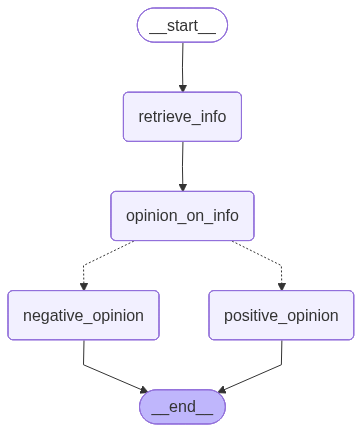

In [ ]:
graph=StateGraph(resultState)

graph.add_node("retrieve_info",retrieve_info)
graph.add_node("opinion_on_info",opinion_on_info)
graph.add_node("positive_opinion",positive_opinion)
graph.add_node("negative_opinion",negative_opinion)

graph.add_edge(START,"retrieve_info")
graph.add_edge('retrieve_info','opinion_on_info')
graph.add_conditional_edges("opinion_on_info",check_condition)
graph.add_edge("positive_opinion",END)
graph.add_edge("negative_opinion",END)
graph.compile()

In [ ]:
workflow=graph.compile()


In [ ]:
#question which is relevant to the pdf
res1=workflow.invoke({"input":"explain me about machine learning"})
print(res1["result"])

Opinion raw: 'positive'
Machine learning (ML), a discipline of AI, gives machines the capability to learn from data and experiences, which allows them to identify patterns and make predictions with little human interaction. These systems gain from large amounts of data and solve specific problems using computer algorithms that increase efficiency with experience. ML systems learn from historical data, build prediction models, and predict the output when they receive new data. The accuracy of these predictions depends on the data volume, with larger amounts of data leading to more accurate models. Instead of coding for specific problems, data is fed to generic algorithms, which build logic and predict outputs. Usage of machine learning varies from self-driving cars to friend recommendations on Facebook, cyber fraud detection, and face recognition. The machine learning model or "hypothesis" is the mathematical representation of a real-world process, which, along with training data, is us

In [ ]:
#question which is relevant to the pdf
res2=workflow.invoke({"input":"explain me about apj abdul kalam"})
print(res2["result"])

Opinion raw: 'negative'
The question you asked is not mentioned in the RAG information


In [ ]:
print(res2)

{'input': 'explain me about apj abdul kalam', 'output': ['PVP Siddhartha Institute of Technology, Department of IT                                                         19 | P a g e  \n \n\uf0b7 It is also used for the  Catalog Design  and Loss-leader Analysis  and many more other \napplications. \n \nClassification: - \nClassification is a supervised machine learn ing method where the model tries to predict the \ncorrect label of a given input data. In classification, the model is fully trained using the training data, \nand then it is evaluated on test data before being used to perform prediction on new unseen data. \nFor instance, an algorithm can learn to predict whether a given email is spam or ham (no spam) \nWe will first understand the difference between the two types of learners in classification: lazy and \neager learners. Then we will clarify the misconception between classification and regression.  \nLazy Learners Vs. Eager Learners \nThere are two types of learners in ma